# Exploratory Data Analysis - UCI Diabetes 130-US Hospitals

30-day readmission prediction. This notebook surveys the raw data: target
balance, missingness, and the clinical signals that motivate the engineered
features (prior inpatient visits, discharge destination, and the
HbA1c x medication-change interaction from Strack et al., 2014).

In [1]:
import sys; sys.path.insert(0, '..')
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.load import load_raw

sns.set_theme(style='whitegrid')
df = load_raw()
df.shape

(101766, 50)

## 1. Target distribution

The raw `readmitted` column has three classes; we model the binary
`<30` vs. rest. The positive class is the minority (~11%), which drives
the SMOTE + recall-oriented threshold design.

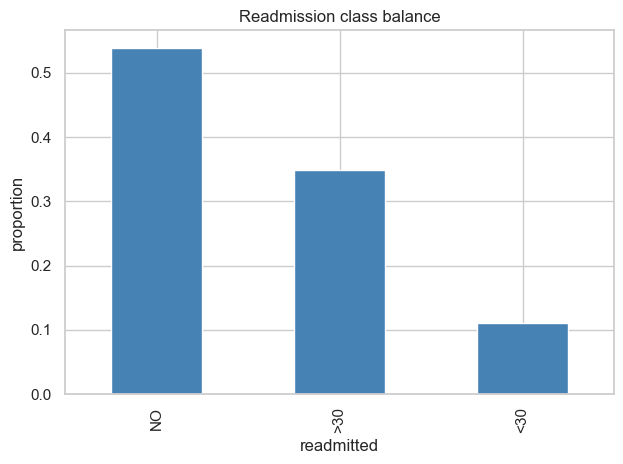

In [2]:
ax = (df['readmitted'].value_counts(normalize=True)
        .reindex(['NO', '>30', '<30']).plot.bar(color='steelblue'))
ax.set_title('Readmission class balance')
ax.set_ylabel('proportion')
plt.tight_layout(); plt.show()

## 2. Missingness

`weight`, `max_glu_serum`, `A1Cresult`, `medical_specialty`, and
`payer_code` are heavily missing. `weight`/`payer_code` are dropped;
`A1Cresult` missingness is itself informative (test not ordered) and is
kept as an explicit category.

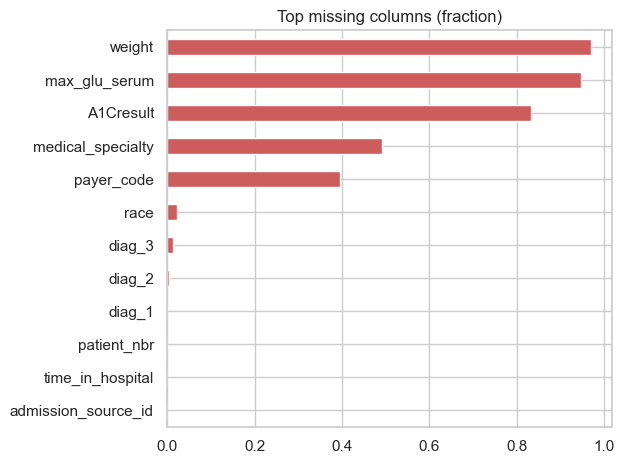

In [3]:
miss = df.isna().mean().sort_values(ascending=False).head(12)
ax = miss.plot.barh(color='indianred')
ax.set_title('Top missing columns (fraction)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 3. Prior inpatient visits vs. readmission

Prior utilization is the strongest single signal in this dataset and
the top SHAP driver in the final model.

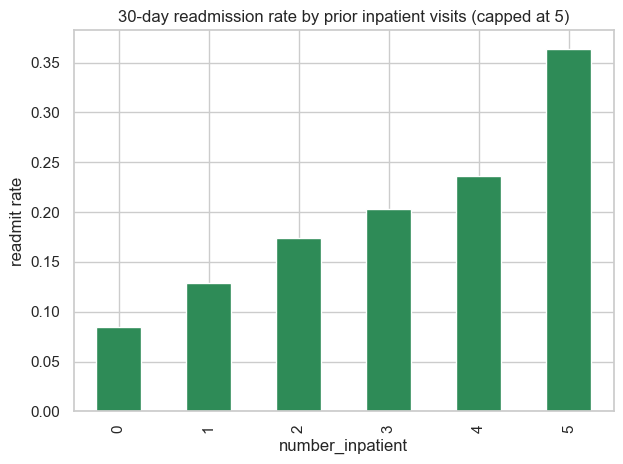

In [4]:
d = df.assign(readmit_30=(df['readmitted'] == '<30').astype(int))
g = d.groupby(d['number_inpatient'].clip(upper=5))['readmit_30'].mean()
ax = g.plot.bar(color='seagreen')
ax.set_title('30-day readmission rate by prior inpatient visits (capped at 5)')
ax.set_xlabel('number_inpatient'); ax.set_ylabel('readmit rate')
plt.tight_layout(); plt.show()

## 4. HbA1c x medication-change interaction (Strack et al., 2014)

The prognostic value of HbA1c is not the level alone but whether a high
result led to a medication change. This motivates the engineered
`a1c_change_group` feature.

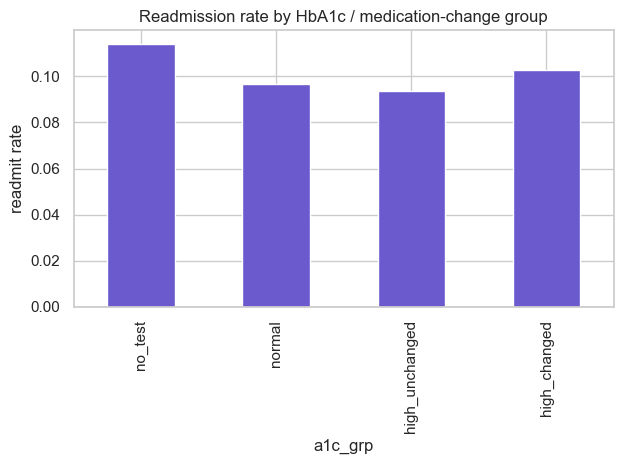

In [5]:
def a1c_group(r):
    a = r['A1Cresult']
    if pd.isna(a): return 'no_test'
    if a == 'Norm': return 'normal'
    return 'high_changed' if r['change'] == 'Ch' else 'high_unchanged'

d['a1c_grp'] = d.apply(a1c_group, axis=1)
order = ['no_test', 'normal', 'high_unchanged', 'high_changed']
ax = d.groupby('a1c_grp')['readmit_30'].mean().reindex(order).plot.bar(color='slateblue')
ax.set_title('Readmission rate by HbA1c / medication-change group')
ax.set_ylabel('readmit rate')
plt.tight_layout(); plt.show()

## Takeaways

- Strong class imbalance -> SMOTE + recall-targeted threshold.
- Informative missingness in `A1Cresult` -> keep as category.
- Prior inpatient utilization and the HbA1c/med-change interaction are
  the most clinically meaningful signals; both are engineered explicitly
  in `src/features/`.